# Model LP2

Model LP2 extends [Model LP](GL06LP.ipynb) from Chapter 5 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` by making bond prices **endogenous** through a target-proportion mechanism and replacing static bond-price expectations with adaptive expectations. In all other respects, LP2 inherits the equations of LP unchanged.

## Module Contents

As with all `MacroStat` models, LP2 is divided into Variables, Parameters (fixed constants), Scenarios, and the Behavior (model initialization and steps). The module-level documentation can be seen in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06LP2/variables.rst>
    Parameters <GL06LP2/parameters.rst>
    Equations <GL06LP2/equations.rst>
    Scenarios <GL06LP2/scenarios.rst>
```

The remainder of this page gives an introduction to the model, notes on how it is implemented in `MacroStat` and then shows some of the model dynamics by replicating the relevant graphs of Godley and Lavoie (2006).

## Model Overview

### Behavioral Equations

Model LP2 inherits equations 1–9 and 13–20 unchanged from [Model LP](GL06LP.ipynb). The static-expectations equation ($p_{bl}^e = p_{bl}$, equation 10 in LP) is replaced by two new equations that make bond prices **endogenous** and expectations **adaptive**.

**New equation 10a — Target Proportion:**
```{math}
:label: gl06_lp2_eq10a_targetProportion
TP(t) = \frac{BL_h(t-1) \cdot p_{bl}(t-1)}
             {BL_h(t-1) \cdot p_{bl}(t-1) + B_h(t-1)}
```
**New equation 10b — Endogenous Bond Price:**
```{math}
:label: gl06_lp2_eq10b_bondPrice
z_1 = 1 \text{ iff } TP > \text{top}, \quad z_2 = 1 \text{ iff } TP < \text{bot}
```
```{math}
:label: gl06_lp2_eq10c_bondPriceAdj
p_{bl}(t) = (1 + z_1 \cdot \beta - z_2 \cdot \beta) \cdot p_{bl}(t-1)
```
**New equation 10d — Adaptive Expectations:**
```{math}
:label: gl06_lp2_eq10d_adaptiveExp
p_{bl}^e(t) = p_{bl}^e(t-1) - \beta_e \cdot \left(p_{bl}^e(t-1) - p_{bl}(t)\right)
```

With adaptive expectations, the expected capital gain $\chi \cdot (p_{bl}^e - p_{bl})/p_{bl}$ in the expected return on bonds $ERr_{bl}$ is no longer zero at each period, generating richer portfolio dynamics than in LP.

### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model LP2
:file: GL06LP2/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model LP2
:file: GL06LP2/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Implementation in MacroStat

Transposing these equations to the `MacroStat` framework, we consider that there are:

1. **Sixteen parameters** (fixed constants): $\alpha_1$, $\alpha_2$, $\theta$, $\chi$, the eight $\lambda$ portfolio coefficients, $\beta$ (bond price adjustment step), $\beta_e$ (expectation adjustment speed), $\text{top}$ (upper target proportion bound), and $\text{bot}$ (lower target proportion bound) (see [Parameters](GL06LP2/parameters.rst))
2. **Two scenario variables**: $G(t)$ and $r_b(t)$ — bond prices are now **endogenous** (see [Scenarios](GL06LP2/scenarios.rst))
3. The remaining tracked series are variables — including the new `TargetProportion` and `ExpectedBondPrice` (see [Variables](GL06LP2/variables.rst))

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

# Import the necessary libraries for plotting
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

# Import the MacroStat model components
from macrostat.models.GL06LP2 import GL06LP2, ParametersGL06LP2, ScenariosGL06LP2

# Custom matplotlib style for the documentation
plt.style.use("../../macrostat.mplstyle")
# We show the logging output in the notebook
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Running the Simulation

First, we run the model without any shocks to see the convergence to the steady state.

In [2]:
params = ParametersGL06LP2()
model = GL06LP2(parameters=params)
model.simulate()
output = model.variables.to_pandas()

We can check that the variables are healthy, meaning the redundant equation $H_h = H_s$ holds and all stocks are positive.

:::{Note}
Due to floating point precision, the redundant equation will not hold exactly. We check that the absolute percentage error is below a tolerance.
:::

In [3]:
model.variables.check_health(tolerance=1e-3)

True

An overview of the first 10 steps of the model:

In [4]:
df = model.variables.to_pandas()
df.head(10).T

,time,0,1,2,3,4,5,6,7,8,9
ConsumptionHousehold,Household,0.0,0.0,0.000000,16.124001,29.123171,40.025520,49.155052,56.800381,63.202782,68.564339
ConsumptionGovernment,Government,0.0,0.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
NationalIncome,Macroeconomy,0.0,0.0,20.000000,36.124001,49.123169,60.025520,69.155052,76.800385,83.202782,88.564339
Taxes,Household,0.0,0.0,3.876000,7.000832,9.621614,11.816236,13.654072,15.193127,16.481977,17.561300
InterestOnBillsHousehold,Household,0.0,0.0,0.000000,0.000000,0.189307,0.342600,0.471316,0.579104,0.669339,0.744877
BondCouponIncomeHousehold,Household,0.0,0.0,0.000000,0.000000,0.334654,0.603168,0.828082,1.016420,1.174195,1.306373
CentralBankProfits,CentralBank,0.0,0.0,0.000000,0.483720,0.491546,0.510596,0.526161,0.539205,0.550126,0.559269
CapitalGains,Household,0.0,0.0,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ExpectedCapitalGains,Household,0.0,0.0,0.000000,0.009906,0.008927,0.006128,0.003761,0.002172,0.001208,0.000655
Wealth,Household,0.0,0.0,16.124001,29.123169,40.025520,49.155052,56.800377,63.202778,68.564339,73.054283


### Convergence to the Steady State

In the steady state of Model LP2, the target proportion $TP$ stabilises within the band $[\text{bot}, \text{top}]$ and bond prices stop adjusting. Adaptive expectations converge to the actual bond price, so $p_{bl}^e \to p_{bl}$, and capital gains vanish in the long run.

The convergence is slower than in LP because of the expectation feedback, but the long-run steady state is qualitatively similar.

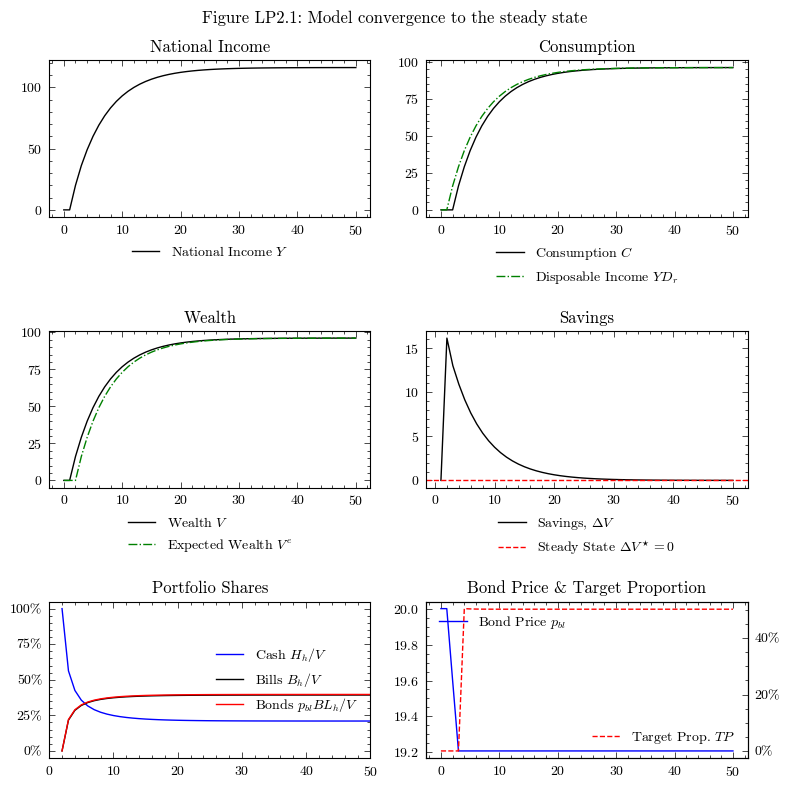

In [5]:
dfo = output.loc[:50]

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(8, 8))

# National Income
axs[0, 0].plot(dfo.index, dfo['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0, 0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[0, 0].set_title('National Income')

# Consumption and Disposable Income
axs[0, 1].plot(dfo.index, dfo['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[0, 1].plot(dfo.index, dfo['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD_r$')
axs[0, 1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[0, 1].set_title('Consumption')

# Wealth
axs[1, 0].plot(dfo.index, dfo['Wealth'], color='k', label=r'Wealth $V$')
axs[1, 0].plot(dfo.index, dfo['ExpectedWealth'], color='g', linestyle='-.', label=r'Expected Wealth $V^e$')
axs[1, 0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[1, 0].set_title('Wealth')

# Savings
axs[1, 1].plot(dfo.index, dfo['Wealth'].diff(), color='k', label=r'Savings, $\Delta V$')
axs[1, 1].axhline(y=0, color='r', linestyle='--', label=r'Steady State $\Delta V^\star=0$')
axs[1, 1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[1, 1].set_title('Savings')

# Portfolio Shares
cash_share = output['HouseholdCashStock'] / output['Wealth']
bill_share = output['HouseholdBillStock'] / output['Wealth']
bond_share = (output['HouseholdBondStock'].mul(output[('BondPrice','Macroeconomy')], axis=0)) / output['Wealth']

axs[2, 0].plot(output.index, cash_share, color='b', label='Cash $H_h/V$')
axs[2, 0].plot(output.index, bill_share, color='k', label='Bills $B_h/V$')
axs[2, 0].plot(output.index, bond_share, color='r', label='Bonds $p_{bl} BL_h/V$')
axs[2, 0].legend(loc='center right', frameon=False)
axs[2, 0].set_xlim(0, 50)
axs[2, 0].set_title('Portfolio Shares')
axs[2, 0].yaxis.set_major_formatter(PercentFormatter(1))

# Bond Price and Target Proportion
ax_bp = axs[2, 1]
ax_tp = ax_bp.twinx()
ax_bp.plot(dfo.index, dfo[('BondPrice', 'Macroeconomy')], color='b', label=r'Bond Price $p_{bl}$')
ax_tp.plot(dfo.index, dfo['TargetProportion'], color='r', linestyle='--', label=r'Target Prop. $TP$')
ax_bp.set_title('Bond Price & Target Proportion')
ax_bp.legend(loc='upper left', frameon=False)
ax_tp.legend(loc='lower right', frameon=False)
ax_tp.yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle('Figure LP2.1: Model convergence to the steady state')
plt.tight_layout()
plt.show()

### Perturbation 1: Rise in the Bill Rate (Section 5.8, first experiment)

Following Section 5.8 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`, we increase the interest rate on Treasury bills from 3% to 4%, but *without* changing the bond price exogenously (unlike Scenario 1 of LP). In LP2, the bond price adjusts endogenously through the target-proportion mechanism.

When $r_b$ rises, bills become more attractive relative to bonds. Households shift their portfolio toward bills, which raises the target proportion $TP$ above the upper threshold. The Treasury responds by allowing bond prices to rise until $TP$ falls back into the target band. This is Figure 5.5 of Godley and Lavoie (2006).

In [6]:
scenarios = ScenariosGL06LP2(parameters=params)
sc1 = scenarios.get_scenario_index("Scenario.1: Rise in bill rate")
model1 = GL06LP2(parameters=params, scenarios=scenarios)
model1.simulate(scenario=sc1)
output_sc1 = model1.variables.to_pandas()

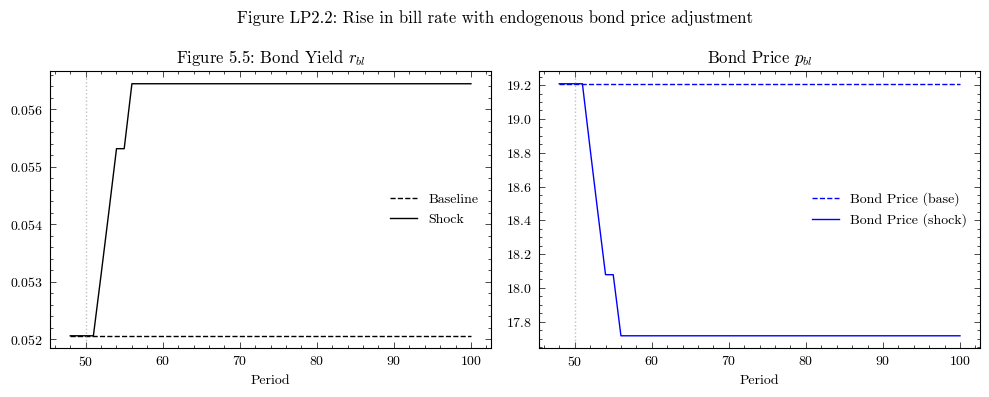

In [10]:
trigger = params["scenario_trigger"]
dfo = output_sc1.loc[trigger - 2:]
dfo_base = output.loc[trigger - 2:]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Figure 5.5: Bond yield
axes[0].plot(dfo_base.index, dfo_base['BondYield'], 'k--', label='Baseline')
axes[0].plot(dfo.index, dfo['BondYield'], 'k-', label='Shock')
axes[0].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[0].set_title('Figure 5.5: Bond Yield $r_{bl}$')
axes[0].set_xlabel('Period')
axes[0].legend(frameon=False)

# Bond Price
axes[1].plot(dfo_base.index, dfo_base[('BondPrice','Macroeconomy')], 'b--', label='Bond Price (base)')
axes[1].plot(dfo.index, dfo[('BondPrice','Macroeconomy')], 'b-', label='Bond Price (shock)')
axes[1].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[1].set_title('Bond Price $p_{bl}$')
axes[1].set_xlabel('Period')
axes[1].legend(frameon=False)

fig.suptitle('Figure LP2.2: Rise in bill rate with endogenous bond price adjustment')
plt.tight_layout()
plt.show()

### Perturbation 2: Anticipated Fall in Bond Prices (Section 5.8, second experiment)

In this experiment, households form a one-period expectation of a fall in the bond price by 1 unit (via an `ExpectedBondPriceShock` of $-1$). The lower expected bond price reduces the expected return on bonds, causing households to demand fewer bonds and more bills and cash.

With adaptive expectations, this shock is only temporary — households gradually revise their expectations back toward the actual bond price. However, while the expectation shock persists, the portfolio reallocation depresses bond demand and, through the target-proportion mechanism, pushes bond prices lower. This is Figure 5.7 of Godley and Lavoie (2006).

In [8]:
sc2 = scenarios.get_scenario_index("Scenario.2: Expected bond price fall")
model2 = GL06LP2(parameters=params, scenarios=scenarios)
model2.simulate(scenario=sc2)
output_sc2 = model2.variables.to_pandas()

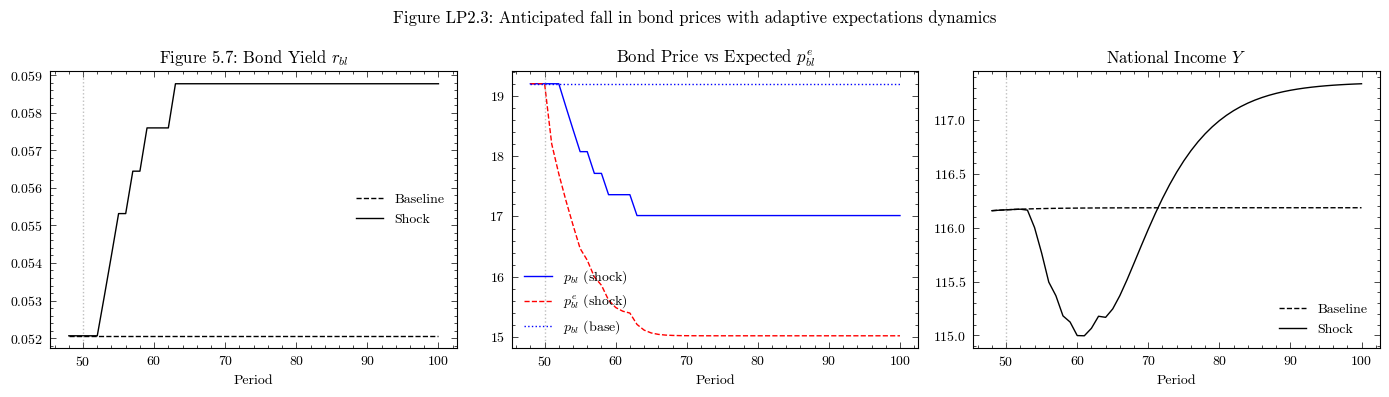

In [11]:
dfo2 = output_sc2.loc[trigger - 2:]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Figure 5.7: Bond yield
axes[0].plot(dfo_base.index, dfo_base['BondYield'], 'k--', label='Baseline')
axes[0].plot(dfo2.index, dfo2['BondYield'], 'k-', label='Shock')
axes[0].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[0].set_title('Figure 5.7: Bond Yield $r_{bl}$')
axes[0].set_xlabel('Period')
axes[0].legend(frameon=False)

# Bond Price vs Expected Bond Price
axes[1].plot(dfo2.index, dfo2[('BondPrice','Macroeconomy')], 'b-', label=r'$p_{bl}$ (shock)')
axes[1].plot(dfo2.index, dfo2['ExpectedBondPrice'], 'r--', label=r'$p_{bl}^e$ (shock)')
axes[1].plot(dfo_base.index, dfo_base[('BondPrice','Macroeconomy')], 'b:', label=r'$p_{bl}$ (base)')
axes[1].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[1].set_title(r'Bond Price vs Expected $p_{bl}^e$')
axes[1].set_xlabel('Period')
axes[1].legend(frameon=False)

# National Income
axes[2].plot(dfo_base.index, dfo_base['NationalIncome'], 'k--', label='Baseline')
axes[2].plot(dfo2.index, dfo2['NationalIncome'], 'k-', label='Shock')
axes[2].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[2].set_title('National Income $Y$')
axes[2].set_xlabel('Period')
axes[2].legend(frameon=False)

fig.suptitle('Figure LP2.3: Anticipated fall in bond prices with adaptive expectations dynamics')
plt.tight_layout()
plt.show()